Using device: cuda


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.89MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.3MB/s]


Model parameters: 305,034
Epoch 1/10
  Train Loss: 1.3815, Train Acc: 0.5009
  Test Loss: 0.7313, Test Acc: 0.7478
Epoch 2/10
  Train Loss: 0.6356, Train Acc: 0.7848
  Test Loss: 0.3616, Test Acc: 0.8893
Epoch 3/10
  Train Loss: 0.3915, Train Acc: 0.8727
  Test Loss: 0.2403, Test Acc: 0.9189
Epoch 4/10
  Train Loss: 0.2852, Train Acc: 0.9092
  Test Loss: 0.1832, Test Acc: 0.9399
Epoch 5/10
  Train Loss: 0.2333, Train Acc: 0.9259
  Test Loss: 0.1762, Test Acc: 0.9431
Epoch 6/10
  Train Loss: 0.1950, Train Acc: 0.9378
  Test Loss: 0.1290, Test Acc: 0.9604
Epoch 7/10
  Train Loss: 0.1681, Train Acc: 0.9465
  Test Loss: 0.1274, Test Acc: 0.9592
Epoch 8/10
  Train Loss: 0.1522, Train Acc: 0.9509
  Test Loss: 0.1239, Test Acc: 0.9626
Epoch 9/10
  Train Loss: 0.1328, Train Acc: 0.9576
  Test Loss: 0.0999, Test Acc: 0.9669
Epoch 10/10
  Train Loss: 0.1232, Train Acc: 0.9606
  Test Loss: 0.1127, Test Acc: 0.9645

Training complete!


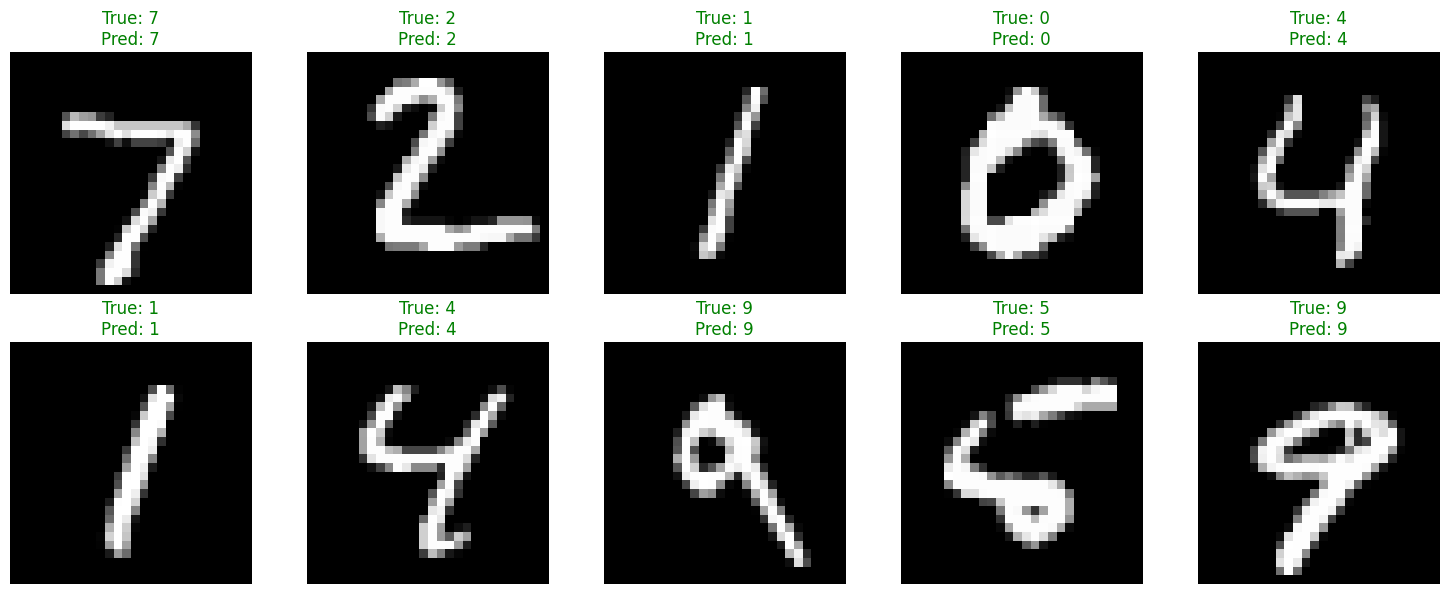

Saved predictions to 'predictions.png'

MODEL ARCHITECTURE SUMMARY
Input: 28x28 images
Patch size: 4x4
Number of patches: 49 = 49
Embedding dimension: 64
Number of transformer blocks: 6
Number of attention heads: 4
Total parameters: 305,034


In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Patch Embedding Layer
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=28, patch_size=4, in_channels=1, embed_dim=64):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)  # (B, embed_dim, H/P, W/P)
        x = x.flatten(2)  # (B, embed_dim, n_patches)
        x = x.transpose(1, 2)  # (B, n_patches, embed_dim)
        return x

# Transformer Encoder Block
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=64, n_heads=4, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, n_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * mlp_ratio),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * mlp_ratio, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # Self-attention with residual
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        # MLP with residual
        x = x + self.mlp(self.norm2(x))
        return x

# Vision Transformer
class VisionTransformer(nn.Module):
    def __init__(self, img_size=28, patch_size=4, in_channels=1, n_classes=10,
                 embed_dim=64, depth=6, n_heads=4, mlp_ratio=4, dropout=0.1):
        super().__init__()

        # Patch embedding
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        n_patches = self.patch_embed.n_patches

        # Class token and position embeddings
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)

        # Transformer encoder
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, n_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, n_classes)

    def forward(self, x):
        B = x.shape[0]

        # Patch embedding
        x = self.patch_embed(x)

        # Add class token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)

        # Add position embedding
        x = x + self.pos_embed
        x = self.dropout(x)

        # Transformer blocks
        for block in self.blocks:
            x = block(x)

        x = self.norm(x)

        # Classification head (use cls token)
        cls = x[:, 0]
        return self.head(cls)

# Training function
def train(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)

# Evaluation function
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)

# Main execution
if __name__ == "__main__":
    # Setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Data
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = datasets.MNIST('data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST('data', train=False, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

    # Model
    model = VisionTransformer(
        img_size=28,
        patch_size=4,
        in_channels=1,
        n_classes=10,
        embed_dim=64,
        depth=6,
        n_heads=4,
        dropout=0.1
    ).to(device)

    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

    # Training setup
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

    # Train
    epochs = 10
    for epoch in range(epochs):
        train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

    print("\nTraining complete!")

        # Visualize predictions
    model.eval()
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()

    # Get some test samples
    test_iter = iter(test_loader)
    imgs, labels = next(test_iter)
    imgs, labels = imgs.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(imgs)
        preds = outputs.argmax(1)

    # Display images with predictions
    for i in range(10):
        img = imgs[i].cpu().squeeze()
        true_label = labels[i].cpu().item()
        pred_label = preds[i].cpu().item()

        axes[i].imshow(img, cmap='gray')
        color = 'green' if true_label == pred_label else 'red'
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label}', color=color)
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig('predictions.png', dpi=100, bbox_inches='tight')
    plt.show()
    print("Saved predictions to 'predictions.png'")

    # Show model architecture summary
    print("\n" + "="*50)
    print("MODEL ARCHITECTURE SUMMARY")
    print("="*50)
    print(f"Input: {28}x{28} images")
    print(f"Patch size: {4}x{4}")
    print(f"Number of patches: {(28//4)**2} = 49")
    print(f"Embedding dimension: 64")
    print(f"Number of transformer blocks: 6")
    print(f"Number of attention heads: 4")
    print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
    print("="*50)